# Laboratorio 5. Análisis de tráfico.
## Security Data Science
### Fabiola Contreras - 22787 

In [1]:
from scapy.all import * 
import pandas as pd 
import numpy as np
import binascii 
import seaborn as sns
sns.set(color_codes=True)
%matplotlib inline

## Sniffing de tráfico

In [3]:
# Captura de paquetes
num_of_packets_to_sniff = 10
pcap = sniff(count=num_of_packets_to_sniff)

# Información del paquete
print("Tipo de dato:", type(pcap))
print("Número de paquetes:", len(pcap))

Tipo de dato: <class 'scapy.plist.PacketList'>
Número de paquetes: 10


In [ ]:
# Impresión del contenido de paquetes:
print("CONTENIDO DEL PCAP\n")

for i, pkt in enumerate(pcap):
    print(f"Paquete #{i+1}")
    
    # Direcciones IP
    src = pkt["IP"].src if pkt.haslayer("IP") else "N/A"
    dst = pkt["IP"].dst if pkt.haslayer("IP") else "N/A"
    
    # Puertos
    sport = "N/A"
    dport = "N/A"
    
    if pkt.haslayer("TCP"):
        sport = pkt["TCP"].sport
        dport = pkt["TCP"].dport
    elif pkt.haslayer("UDP"):
        sport = pkt["UDP"].sport
        dport = pkt["UDP"].dport
    
    # Longitud del paquete
    length = len(pkt)
    
    # Mostrar resultados
    print(f"  Src Address : {src}")
    print(f"  Dst Address : {dst}")
    print(f"  Src Port    : {sport}")
    print(f"  Dst Port    : {dport}")
    print(f"  Length      : {length}")
    print(f"  Summary     : {pkt.summary()}")
    print("-" * 40)


CONTENIDO DEL PCAP

Paquete #1
  Src Address : N/A
  Dst Address : N/A
  Src Port    : N/A
  Dst Port    : N/A
  Length      : 60
  Summary     : Ether / ARP who has 192.168.1.13 says 192.168.1.1 / Padding
----------------------------------------
Paquete #2
  Src Address : N/A
  Dst Address : N/A
  Src Port    : N/A
  Dst Port    : N/A
  Length      : 42
  Summary     : Ether / ARP is at 20:4e:f6:5b:67:49 says 192.168.1.13
----------------------------------------
Paquete #3
  Src Address : N/A
  Dst Address : N/A
  Src Port    : N/A
  Dst Port    : N/A
  Length      : 150
  Summary     : Ether / IPv6 / ICMPv6ND_RA / ICMPv6NDOptRDNSS / ICMPv6NDOptPrefixInfo / ICMPv6 Neighbor Discovery Option - Source Link-Layer Address bc:5b:d5:b6:ae:8a
----------------------------------------
Paquete #4
  Src Address : 192.168.1.13
  Dst Address : 239.255.255.250
  Src Port    : N/A
  Dst Port    : N/A
  Length      : 46
  Summary     : Ether / 192.168.1.13 > 239.255.255.250 2 / Raw
------------------

## Leer un PCAP de Wireshark

In [6]:
pcap = rdpcap("analisis_paquetes.pcap")

## Convertir PCAP a un DataFrame

Scapy es una librería muy versatil, pero sus estructuras de datos no son tan fáciles de manipular como un data frame

In [7]:
# Collect field names from IP/TCP/UDP (These will be columns in DF)
ip_fields = [field.name for field in IP().fields_desc]
tcp_fields = [field.name for field in TCP().fields_desc]
udp_fields = [field.name for field in UDP().fields_desc]

dataframe_fields = ip_fields + ['time'] + tcp_fields + ['payload','payload_raw','payload_hex']

# Create blank DataFrame
df = pd.DataFrame(columns=dataframe_fields)
for packet in pcap[IP]:
    # Field array for each row of DataFrame
    field_values = []
    # Add all IP fields to dataframe
    for field in ip_fields:
        if field == 'options':
            # Retrieving number of options defined in IP Header
            field_values.append(len(packet[IP].fields[field]))
        else:
            field_values.append(packet[IP].fields[field])
    
    field_values.append(packet.time)
    
    layer_type = type(packet[IP].payload)
    for field in tcp_fields:
        try:
            if field == 'options':
                field_values.append(len(packet[layer_type].fields[field]))
            else:
                field_values.append(packet[layer_type].fields[field])
        except:
            field_values.append(None)
    
    # Append payload
    field_values.append(len(packet[layer_type].payload))
    field_values.append(packet[layer_type].payload.original)
    field_values.append(binascii.hexlify(packet[layer_type].payload.original))
    # Add row to DF
    df_append = pd.DataFrame([field_values], columns=dataframe_fields)
    df = pd.concat([df, df_append], axis=0)

# Reset Index
df = df.reset_index()
# Drop old index column
df = df.drop(columns="index")

In [8]:
df.shape

(62, 28)

## Estadísticas

In [16]:
ip_origen_frecuente = df['src'].value_counts().idxmax()
print("IP origen más frecuente:", ip_origen_frecuente)

IP origen más frecuente: 10.1.10.53


In [17]:
ip_destino_frecuente = df['dst'].value_counts().idxmax()
print("IP destino más frecuente:", ip_destino_frecuente)

IP destino más frecuente: 10.1.10.53


In [19]:
ips_comunicadas = df[df['src'] == ip_origen_frecuente]['dst'].unique()
print("IPs con las que se comunica:\n", ips_comunicadas)

IPs con las que se comunica:
 ['84.54.22.33' '75.75.75.75']


In [20]:
puertos_destino = df[df['src'] == ip_origen_frecuente]['dport'].dropna().unique()
print("Puertos destino:", puertos_destino)

Puertos destino: [53]


In [22]:
puertos_origen = df[df['dst'] == ip_destino_frecuente]['sport'].dropna().unique()
print("Puertos origen:", puertos_origen)

Puertos origen: [53]


### ¿Cuál es el propósito de los puertos que más aparecen en los incisos d y e?
En ambos incisos aparece el puerto 53. Este puerto se utiliza para el sistema de nombres de dominio (DNS), encargado de traducir nombres de dominio en direcciones IP, por lo que es común observarlo frecuentemente en el tráfico de red.

In [24]:
df['payload_len'] = df['payload']

mean = df['payload_len'].mean()
std = df['payload_len'].std()

df['z_score'] = (df['payload_len'] - mean) / std

# Paquetes anómalos
anomalias_2 = df[np.abs(df['z_score']) > 2]
anomalias_3 = df[np.abs(df['z_score']) > 3]

print("Z > 2:\n", anomalias_2[['payload_len', 'z_score']])
print("\nZ > 3:\n", anomalias_3[['payload_len', 'z_score']])

Z > 2:
 Empty DataFrame
Columns: [payload_len, z_score]
Index: []

Z > 3:
 Empty DataFrame
Columns: [payload_len, z_score]
Index: []


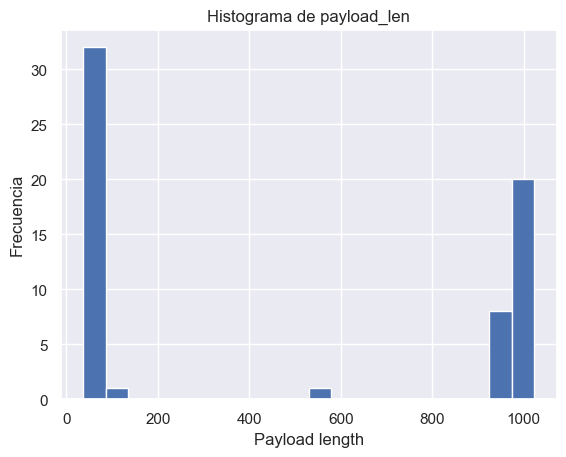

In [25]:
import matplotlib.pyplot as plt

plt.hist(df['payload_len'], bins=20)
plt.xlabel("Payload length")
plt.ylabel("Frecuencia")
plt.title("Histograma de payload_len")
plt.show()

La distribución no es normal, sino sesgada o con múltiples picos. El Z-score asume normalidad, por lo que pierde efectividad para detectar valores atípicos en este caso.

In [26]:
mean_dns = 50
std_dns = 15

df['z_score_dns'] = (df['payload_len'] - mean_dns) / std_dns

anomalias_dns = df[np.abs(df['z_score_dns']) > 2]

print(anomalias_dns[['payload_len', 'z_score_dns']])
print("Cantidad de anomalías:", len(anomalias_dns))

   payload_len z_score_dns
0          933   58.866667
2          947        59.8
4          984   62.266667
6          970   61.333333
8          975   61.666667
10        1017   64.466667
12         980        62.0
14         951   60.066667
16         931   58.733333
18         964   60.933333
20        1023   64.866667
25          89         2.6
26         978   61.866667
28         958   60.533333
30         976   61.733333
32        1009   63.933333
34         976   61.733333
36        1011   64.066667
38        1009   63.933333
40        1007        63.8
42         982   62.133333
44         978   61.866667
46         978   61.866667
48         985   62.333333
50         991   62.733333
52         977        61.8
54         989        62.6
56         999   63.266667
58         941        59.4
60         560        34.0
Cantidad de anomalías: 30


**¿Qué paquetes se detectan ahora como anómalos? ¿Cuántos paquetes fueron detectados?**
Un paquete se considera anómalo si su tamaño se desvía más de dos desviaciones estándar del valor típico esperado para DNS, en este caso, los que se encuentran fuera del rango aproximado de 20 a 80 bytes. De esta forma se detectaron 30 paquetes anómalos.

**¿Qué nos enseña esto sobre la importancia de conocer el o los protocolos a analizar al aplicar técnicas de detección de anomalías?**
Este análisis demuestra que el uso de conocimiento del protocolo es fundamental, ya que métodos estadísticos generales pueden fallar si los datos no siguen una distribución adecuada, mientras que valores de referencia específicos permiten detectar anomalías con mayor precisión.

## Gráficas de payload

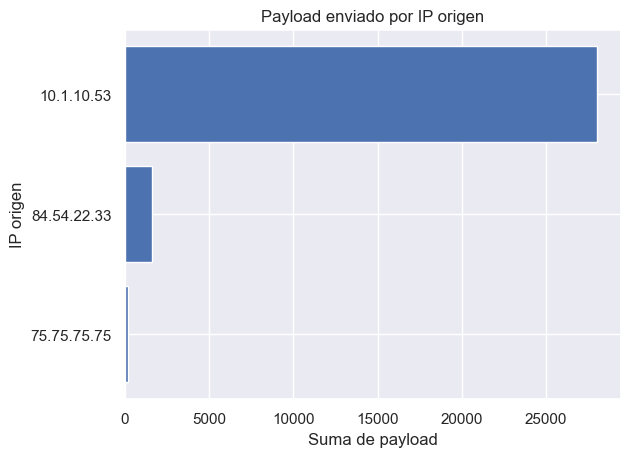

In [29]:
group_src = df.groupby('src')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(group_src.index.astype(str), group_src.values)
plt.xlabel("Suma de payload")
plt.ylabel("IP origen")
plt.title("Payload enviado por IP origen")
plt.show()

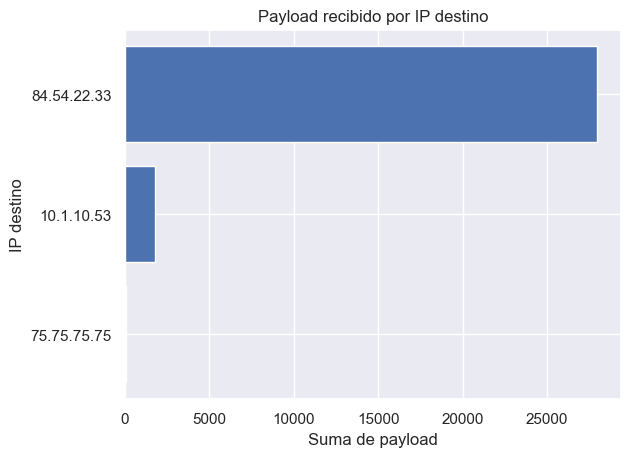

In [30]:
group_dst = df.groupby('dst')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(group_dst.index.astype(str), group_dst.values)
plt.xlabel("Suma de payload")
plt.ylabel("IP destino")
plt.title("Payload recibido por IP destino")
plt.show()

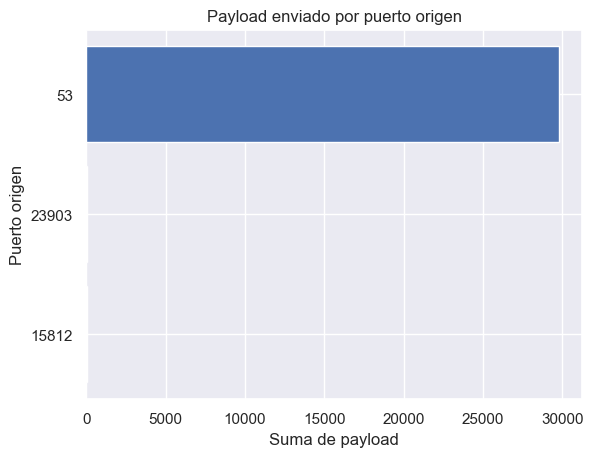

In [31]:
group_sport = df.dropna(subset=['sport']).groupby('sport')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(group_sport.index.astype(str), group_sport.values)
plt.xlabel("Suma de payload")
plt.ylabel("Puerto origen")
plt.title("Payload enviado por puerto origen")
plt.show()

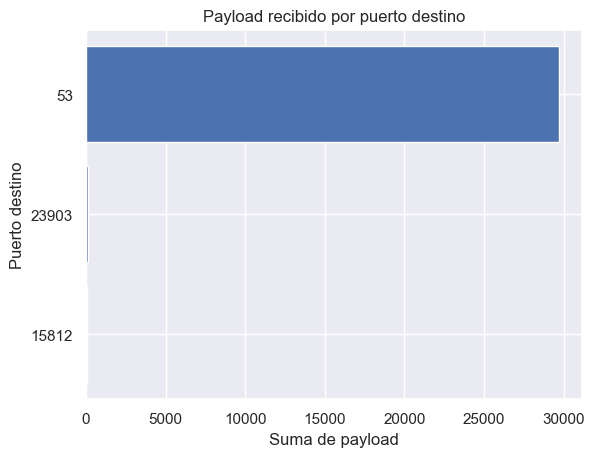

In [32]:
group_dport = df.dropna(subset=['dport']).groupby('dport')['payload_len'].sum().sort_values()

plt.figure()
plt.barh(group_dport.index.astype(str), group_dport.values)
plt.xlabel("Suma de payload")
plt.ylabel("Puerto destino")
plt.title("Payload recibido por puerto destino")
plt.show()

## Isolation Forest

In [37]:
from sklearn.ensemble import IsolationForest

# Seleccionar columnas numéricas
X = df[['payload_len', 'len']]  # 'len' es pkt_len en IP

# Calcular contamination correctamente
contamination = len(anomalias_dns) / len(df)

# Modelo
model = IsolationForest(contamination=contamination, random_state=42)

# Entrenar
model.fit(X)

# Predicciones (-1 = anomalía, 1 = normal)
df['anomaly_iforest'] = model.predict(X)

# Filtrar anomalías
anomalias_iforest = df[df['anomaly_iforest'] == -1]

print("Cantidad de anomalías:", len(anomalias_iforest))
print(anomalias_iforest[['src', 'dst', 'payload_len', 'len']])

Cantidad de anomalías: 30
            src          dst payload_len   len
0    10.1.10.53  84.54.22.33         933   961
2    10.1.10.53  84.54.22.33         947   975
4    10.1.10.53  84.54.22.33         984  1012
6    10.1.10.53  84.54.22.33         970   998
8    10.1.10.53  84.54.22.33         975  1003
10   10.1.10.53  84.54.22.33        1017  1045
12   10.1.10.53  84.54.22.33         980  1008
14   10.1.10.53  84.54.22.33         951   979
16   10.1.10.53  84.54.22.33         931   959
18   10.1.10.53  84.54.22.33         964   992
20   10.1.10.53  84.54.22.33        1023  1051
22   10.1.10.53  75.75.75.75          37    65
23   10.1.10.53  75.75.75.75          37    65
24  75.75.75.75   10.1.10.53          77   105
25  75.75.75.75   10.1.10.53          89   117
28   10.1.10.53  84.54.22.33         958   986
30   10.1.10.53  84.54.22.33         976  1004
32   10.1.10.53  84.54.22.33        1009  1037
34   10.1.10.53  84.54.22.33         976  1004
36   10.1.10.53  84.54.22.33      

Los paquetes marcados como anomalías corresponden principalmente a tráfico entre la IP 10.1.10.53 y la IP 84.54.22.33, con tamaños de payload elevados (alrededor de 900 a 1000 bytes). También se identifican algunos paquetes hacia y desde la IP 75.75.75.75 con tamaños de payload significativamente menores.

**¿Las anomalías detectadas coinciden con las IPs o conversaciones sospechosas que identificó con los Z-score?**
Sí, existe coincidencia parcial. El método basado en Z-score con conocimiento de dominio identificó anomalías principalmente en paquetes con tamaños de payload fuera del rango típico de DNS. De manera similar, Isolation Forest detecta tanto paquetes muy grandes como muy pequeños. Sin embargo, Isolation Forest logra capturar patrones más complejos, identificando grupos de tráfico inusual entre ciertas IPs específicas, como la comunicación frecuente entre 10.1.10.53 y 84.54.22.33.


Isolation Forest puede detectar anomalías más allá de simples umbrales estadísticos, considerando la estructura y comportamiento del tráfico en el conjunto de datos.

## Investigación de payload

In [ ]:
df_original = df.copy() # Guardar el df original para analisis proximos

# Usamos la variable que definimos antes para la IP de origen más frecuente
# Filtrar DataFrame
df_filtrado = df[df['src'] == ip_origen_frecuente]

print("IP origen más frecuente:", ip_origen_frecuente)
print(df_filtrado.shape)

IP origen más frecuente: 10.1.10.53
(31, 32)


In [42]:
df_grouped = df.groupby(['src', 'dst'])['payload_len'].sum().reset_index()

df_grouped.columns = ['Src Address', 'Dst Address', 'Payload Total']

print(df_grouped)

   Src Address  Dst Address Payload Total
0   10.1.10.53  75.75.75.75            74
1   10.1.10.53  84.54.22.33         27979
2  75.75.75.75   10.1.10.53           166
3  84.54.22.33   10.1.10.53          1624


In [ ]:
# Obtención de la IP que más ha intercambiado bytes con la IP más frecuente
# Filtrar tráfico donde participa la IP más frecuente
df_ip = df[(df['src'] == ip_origen_frecuente) | (df['dst'] == ip_origen_frecuente)]

# Crear columna 'peer' para identificar la IP con la que se comunica
df_ip['peer'] = df_ip.apply(
    lambda row: row['dst'] if row['src'] == ip_origen_frecuente else row['src'],
    axis=1
)

# Sumar bytes intercambiados
bytes_por_ip = df_ip.groupby('peer')['payload_len'].sum()

ip_mas_interaccion = bytes_por_ip.idxmax()

print("IP más frecuente:", ip_origen_frecuente)
print("IP con más intercambio:", ip_mas_interaccion)

IP más frecuente: 10.1.10.53
IP con más intercambio: 84.54.22.33


La IP que más ha intercambiado bytes con la IP más frecuente es 84.54.22.33, lo cual coincide con la IP sospechosa identificada previamente mediante técnicas como Z-score e Isolation Forest, ya que concentra gran parte del tráfico.

In [47]:
# DataFrame con la conversación entre ambas IPs
ip_sospechosa = ip_mas_interaccion

df_conversacion = df[
    ((df['src'] == ip_origen_frecuente) & (df['dst'] == ip_sospechosa)) |
    ((df['src'] == ip_sospechosa) & (df['dst'] == ip_origen_frecuente))
]

print(df_conversacion.shape)

(58, 32)


In [50]:
# Extraer payloads a un array
payload_array = df_conversacion['payload_raw'].tolist()

print(payload_array[0])

b'\x00\x0c\x01\x00\x00\x01\x00\x00\x00\x00\x00\x00\x06google\x03com\x00\x00\x1c\x00\x01\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd<\xef\xbf\xbd\xef\xbf\xbdL\x12\xef\xbf\xbd$3wf\xef\xbf\xbd\xef\xbf\xbd\x02<_\r\xef\xbf\xbdY\xef\xbf\xbdr\xef\xbf\xbd\xef\xbf\xbdy\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\x1c\r\x18\xef\xbf\xbd8c\xef\xbf\xbdew\r\x1e\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf

**¿Encuentra algún dato que no haga sentido que se envíe a través del puerto explicado en el inciso 3f? ¿En qué consiste el ataque detectado?**
Se puede ver datos binarios que incluyen la firma de un archivo PNG, lo que no corresponde al uso normal del puerto 53. El protocolo DNS está diseñado para consultas pequeñas de resolución de nombres, no para transferir archivos. Esto indica la presencia de un ataque de tipo *DNS tunneling*, en el cual se utiliza el protocolo DNS para ocultar o transmitir información de manera encubierta.

**¿Por qué es importante combinar técnicas automáticas con investigación manual del payload?**
Los métodos automáticos permiten identificar patrones anómalos de forma rápida y a gran escala, pero no explican el contexto ni el tipo de ataque. En cambio, el análisis manual del contenido permite entender los datos y contexto del tráfico, como en este caso donde se identificó contenido no propio de DNS, revelando un posible ataque de tunneling.